In [1]:
import os
import sys
import datetime

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))

print("done")


done


In [2]:
BASE_DIR = "/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision"
FIGURE_DATA_DIR = os.path.join(BASE_DIR, "figure_data")
FIGURE_S9_DATA_PATH = os.path.join(FIGURE_DATA_DIR, "FigureS9.nc")

scrip_ne30 = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
scrip_ne60 = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc"

city_lonlat = {
    'London': [360 - 0.1319, 51.4947],
    'Exeter': [360 - 3.5325, 50.7251],
    'Cardiff': [360 - 3.1763, 51.4817],
    'Birmingham': [360 - 1.9182, 52.4813],
    'Manchester': [360 - 2.2379, 53.4815],
    'Sheffield': [360 - 1.4781, 53.3786],
    'Edinburgh': [360 - 3.1822, 55.9456],
    'Belfast': [360 - 5.9288, 54.5997],
}

configs = [
    {
        'name': 'ne30x16',
        'se_base_files': (
            "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/"
            "MUSICA_production3.2_BB/atm/hist/"
            "MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc"
        ),
        'scrip_file': scrip_ne30,
        'start_date': datetime.date(2018, 5, 27),
        'end_date': datetime.date(2018, 5, 30),
        'city_lonlat': city_lonlat,
    },
    {
        'name': 'ne60',
        'se_base_files': (
            "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/"
            "MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc"
        ),
        'scrip_file': scrip_ne60,
        'start_date': datetime.date(2018, 5, 27),
        'end_date': datetime.date(2018, 5, 30),
        'city_lonlat': city_lonlat,
    },
    {
        'name': 'regrid',
        'se_base_files': (
            "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regridded/"
            "regrid_to_ne60_MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc"
        ),
        'scrip_file': scrip_ne60,
        'start_date': datetime.date(2018, 5, 27),
        'end_date': datetime.date(2018, 5, 30),
        'city_lonlat': city_lonlat,
    },
]

cities = [
    'London', 'Exeter', 'Cardiff', 'Birmingham',
    'Manchester', 'Sheffield', 'Edinburgh', 'Belfast',
]

vars_model = {
    'Surface Temperature': 'T',
    'Precipitation': 'PRECT',
    'CO': 'CO',
    'Wind Speed (U)': 'U',
    'Wind Speed (V)': 'V',
}

pollutants = list(vars_model.keys())


In [3]:
class HandlerBoxPlot(HandlerBase):
    def __init__(self,
                 sx=1.0, sy=1.8, lw=2.0,
                 box_h_frac=0.75, box_w_frac=0.55,
                 whisk_out_frac=0.35, cap_hfrac=0.30,
                 edgecolor='k', median_color='orange',
                 whisker_color='k', cap_color='k',
                 whisker_linestyle='--',
                 **kwargs):
        super().__init__(**kwargs)
        self.sx = sx
        self.sy = sy
        self.lw = lw
        self.box_h_frac = box_h_frac
        self.box_w_frac = box_w_frac
        self.whisk_out_frac = whisk_out_frac
        self.cap_hfrac = cap_hfrac
        self.edgecolor = edgecolor
        self.median_color = median_color
        self.whisker_color = whisker_color
        self.cap_color = cap_color
        self.whisker_linestyle = whisker_linestyle

    def create_artists(self, legend, orig_handle, x0, y0, w, h, fontsize, trans):
        xc, yc = x0 + w / 2, y0 + h / 2
        w *= self.sx
        h *= self.sy
        x0 = xc - w / 2
        y0 = yc - h / 2
        box_w = w * self.box_w_frac
        box_h = h * self.box_h_frac
        box_x = x0 + (w - box_w) / 2
        box_y = y0 + (h - box_h) / 2
        whisk = box_w * self.whisk_out_frac
        y_mid = y0 + h / 2
        chf = self.cap_hfrac

        box = Rectangle((box_x, box_y), box_w, box_h,
                        fill=False, edgecolor=self.edgecolor,
                        lw=self.lw, transform=trans)
        med = Line2D([box_x + box_w / 2, box_x + box_w / 2],
                     [box_y, box_y + box_h], color=self.median_color,
                     lw=self.lw, transform=trans)
        wl = Line2D([box_x - whisk, box_x], [y_mid, y_mid],
                    color=self.whisker_color, lw=self.lw,
                    linestyle=self.whisker_linestyle, transform=trans)
        wr = Line2D([box_x + box_w, box_x + box_w + whisk], [y_mid, y_mid],
                    color=self.whisker_color, lw=self.lw,
                    linestyle=self.whisker_linestyle, transform=trans)
        capl = Line2D([box_x - whisk, box_x - whisk],
                      [y_mid - chf * h / 2, y_mid + chf * h / 2],
                      color=self.cap_color, lw=self.lw, transform=trans)
        capr = Line2D([box_x + box_w + whisk, box_x + box_w + whisk],
                      [y_mid - chf * h / 2, y_mid + chf * h / 2],
                      color=self.cap_color, lw=self.lw, transform=trans)
        return [wl, wr, capl, capr, box, med]


def load_and_compute_stats(config, cities, vars_model, box_deg=1.0, buffer_deg=0.2):
    with xr.open_dataset(config['scrip_file']) as grid:
        lon360 = grid['grid_center_lon'].values
        lat = grid['grid_center_lat'].values

    lon180 = (lon360 + 180) % 360 - 180
    half = box_deg / 2.0 + buffer_deg

    se_files = []
    cur = config['start_date']
    while cur <= config['end_date']:
        mm, dd = cur.strftime("%m"), cur.strftime("%d")
        fp = config['se_base_files'].replace("MM", mm).replace("DD", dd)
        if os.path.exists(fp):
            se_files.append(fp)
        else:
            print(f"Warning: skip {fp}")
        cur += datetime.timedelta(days=1)

    if len(se_files) == 0:
        raise FileNotFoundError("No input files found")

    ds = xr.open_mfdataset(se_files, combine="by_coords")
    stats = {city: {} for city in cities}

    for city in cities:
        lon360_c, lat_c = config['city_lonlat'][city]
        lon180_c = (lon360_c + 180) % 360 - 180
        diff_lon = (lon180 - lon180_c + 180) % 360 - 180
        mask = (np.abs(lat - lat_c) <= half) & (np.abs(diff_lon) <= half)
        idx = np.where(mask)[0]

        if idx.size == 0:
            dist2 = (lat - lat_c) ** 2 + diff_lon ** 2
            idx = np.array([np.argmin(dist2)])
            print(f"{city} no point, then change to 1")

        for name, var in vars_model.items():
            data = ds[var].values
            if name in ['BC', 'Precipitation']:
                arr = data[:, idx]
            else:
                arr = data[:, -1, idx]

            std = np.nanstd(arr, axis=1)
            mean = np.nanmean(arr, axis=1)
            nsv = np.divide(
                std,
                mean,
                out=np.full_like(mean, np.nan),
                where=np.isfinite(mean) & (mean != 0),
            )
            stats[city][name] = {'nsv': nsv}

    ds.close()
    return stats


In [4]:
style_dicts = {
    'ne30x16': {
        'facecolor': 'none',
        'edgecolor': 'salmon',
        'box_linewidth': 1.0,
        'median_color': 'darksalmon',
        'median_linewidth': 1.0,
        'whisker_color': 'salmon',
        'whisker_linewidth': 1.0,
        'cap_color': 'salmon',
        'cap_linewidth': 0.9,
        'mean_markeredgecolor': 'salmon',
        'mean_markeredgewidth': 0.8,
        'box_width': 0.25,
    },
    'ne60': {
        'facecolor': 'none',
        'edgecolor': 'cornflowerblue',
        'box_linewidth': 1.0,
        'median_color': 'darkblue',
        'median_linewidth': 1.0,
        'whisker_color': 'cornflowerblue',
        'whisker_linewidth': 1.0,
        'cap_color': 'cornflowerblue',
        'cap_linewidth': 0.9,
        'mean_markeredgecolor': 'cornflowerblue',
        'mean_markeredgewidth': 0.8,
        'box_width': 0.25,
    },
    'regrid': {
        'facecolor': 'none',
        'edgecolor': 'orange',
        'box_linewidth': 1.0,
        'median_color': 'darkorange',
        'median_linewidth': 1.0,
        'whisker_color': 'orange',
        'whisker_linewidth': 1.0,
        'cap_color': 'orange',
        'cap_linewidth': 0.9,
        'mean_markeredgecolor': 'orange',
        'mean_markeredgewidth': 0.8,
        'box_width': 0.25,
    },
}

nsv_yaxis_settings = {
    'Surface Temperature': {'interval': 0.2, 'ylim': (0, 1.5)},
    'Precipitation': {'interval': 100, 'ylim': (0, 600)},
    'CO': {'interval': 5, 'ylim': (0, 35)},
    'Wind Speed (U)': {'interval': 25, 'ylim': (-160, 25)},
    'Wind Speed (V)': {'interval': 50, 'ylim': (-200, 50)},
}


def add_boxplot_legend(ax):
    class Ne30Handle:
        pass

    class Ne60Handle:
        pass

    class RegridHandle:
        pass

    handles = [Ne30Handle(), Ne60Handle(), RegridHandle()]
    labels = ['ne30x16', 'ne60', 'ne30x16 (R)']
    handler_map = {
        Ne30Handle: HandlerBoxPlot(
            sx=1.0, sy=1.8, lw=style_dicts['ne30x16']['box_linewidth'],
            box_w_frac=style_dicts['ne30x16']['box_width'] * 1.6,
            whisk_out_frac=style_dicts['ne30x16']['whisker_linewidth'] * 0.3,
            edgecolor=style_dicts['ne30x16']['edgecolor'],
            median_color=style_dicts['ne30x16']['median_color'],
            whisker_color=style_dicts['ne30x16']['whisker_color'],
            cap_color=style_dicts['ne30x16']['cap_color'],
        ),
        Ne60Handle: HandlerBoxPlot(
            sx=1.0, sy=1.8, lw=style_dicts['ne60']['box_linewidth'],
            box_w_frac=style_dicts['ne60']['box_width'] * 1.6,
            whisk_out_frac=style_dicts['ne60']['whisker_linewidth'] * 0.3,
            edgecolor=style_dicts['ne60']['edgecolor'],
            median_color=style_dicts['ne60']['median_color'],
            whisker_color=style_dicts['ne60']['whisker_color'],
            cap_color=style_dicts['ne60']['cap_color'],
        ),
        RegridHandle: HandlerBoxPlot(
            sx=1.0, sy=1.8, lw=style_dicts['regrid']['box_linewidth'],
            box_w_frac=style_dicts['regrid']['box_width'] * 1.6,
            whisk_out_frac=style_dicts['regrid']['whisker_linewidth'] * 0.3,
            edgecolor=style_dicts['regrid']['edgecolor'],
            median_color=style_dicts['regrid']['median_color'],
            whisker_color=style_dicts['regrid']['whisker_color'],
            cap_color=style_dicts['regrid']['cap_color'],
            whisker_linestyle='--',
        ),
    }
    ax.legend(
        handles,
        labels,
        handler_map=handler_map,
        loc='upper right',
        bbox_to_anchor=(1.0, 1.0),
        fontsize=9.3,
        frameon=False,
        handlelength=2.5,
        handletextpad=0.25,
        labelspacing=0.2,
        borderaxespad=0.0,
    )


def draw_nsv_panel(ax, get_nsv_values, pollutant, panel_letter,
                   show_ylabel=False, show_legend=False):
    yset = nsv_yaxis_settings[pollutant]
    x = np.arange(len(cities))

    for j, cfg in enumerate(configs):
        cfg_name = cfg['name']
        sty = style_dicts[cfg_name]
        w = sty['box_width']
        positions = x + (j - (len(configs) - 1) / 2) * w
        data = [get_nsv_values(cfg_name, pollutant, city) for city in cities]

        ax.boxplot(
            data,
            positions=positions,
            widths=w,
            whis=[0, 100],
            patch_artist=True,
            boxprops=dict(facecolor=sty['facecolor'],
                          edgecolor=sty['edgecolor'],
                          linewidth=sty['box_linewidth']),
            medianprops=dict(color=sty['median_color'],
                             linewidth=sty['median_linewidth']),
            whiskerprops=dict(color=sty['whisker_color'],
                              linewidth=sty['whisker_linewidth'],
                              linestyle='--'),
            capprops=dict(color=sty['cap_color'],
                          linewidth=sty['cap_linewidth']),
            showmeans=True,
            meanprops={
                'marker': 'd',
                'markerfacecolor': sty['mean_markeredgecolor'],
                'markeredgecolor': sty['mean_markeredgecolor'],
                'markeredgewidth': sty['mean_markeredgewidth'],
                'markersize': 3.0,
            },
        )

    ax.set_title(pollutant, fontsize=14, pad=5, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=40, ha='right', fontsize=12.5)
    ax.set_xlim(-0.6, len(cities) - 0.4)
    ax.set_ylim(*yset['ylim'])
    ax.yaxis.set_major_locator(MultipleLocator(yset['interval']))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(axis='y', which='major', labelsize=14, pad=2, length=3, width=0.7)
    ax.tick_params(axis='y', which='minor', length=1.8, width=0.6)
    ax.tick_params(axis='x', which='major', pad=2, length=3, width=0.7)
    ax.yaxis.set_tick_params(labelleft=True, labelright=False, left=True, right=False)

    if show_ylabel:
        ax.set_ylabel("NSV (%)", fontsize=14, labelpad=1)
    else:
        ax.set_ylabel("")

    ax.text(0.02, 0.95, panel_letter,
            transform=ax.transAxes, fontsize=11,
            fontweight='bold', va='top', ha='left')

    if show_legend:
        add_boxplot_legend(ax)


def draw_figure_s9(get_nsv_values):
    fig = plt.figure(figsize=(10.3, 6.15), dpi=300)

    left = 0.070
    right = 0.965
    top_gap = 0.055
    panel_w = (right - left - 2 * top_gap) / 3
    panel_h = 0.335
    top_y = 0.595
    bottom_y = 0.085

    top_x = [left + i * (panel_w + top_gap) for i in range(3)]
    bottom_gap = 0.055
    bottom_left = (1 - (2 * panel_w + bottom_gap)) / 2
    bottom_x = [bottom_left, bottom_left + panel_w + bottom_gap]

    panel_specs = [
        ('Surface Temperature', [top_x[0], top_y, panel_w, panel_h], '(a)', True, False),
        ('Precipitation', [top_x[1], top_y, panel_w, panel_h], '(b)', False, False),
        ('CO', [top_x[2], top_y, panel_w, panel_h], '(c)', False, True),
        ('Wind Speed (U)', [bottom_x[0], bottom_y, panel_w, panel_h], '(d)', True, False),
        ('Wind Speed (V)', [bottom_x[1], bottom_y, panel_w, panel_h], '(e)', False, False),
    ]

    axes = {}
    for pollutant, rect, letter, show_ylabel, show_legend in panel_specs:
        ax = fig.add_axes(rect)
        draw_nsv_panel(
            ax,
            get_nsv_values,
            pollutant,
            letter,
            show_ylabel=show_ylabel,
            show_legend=show_legend,
        )
        axes[pollutant] = ax

    return fig, axes


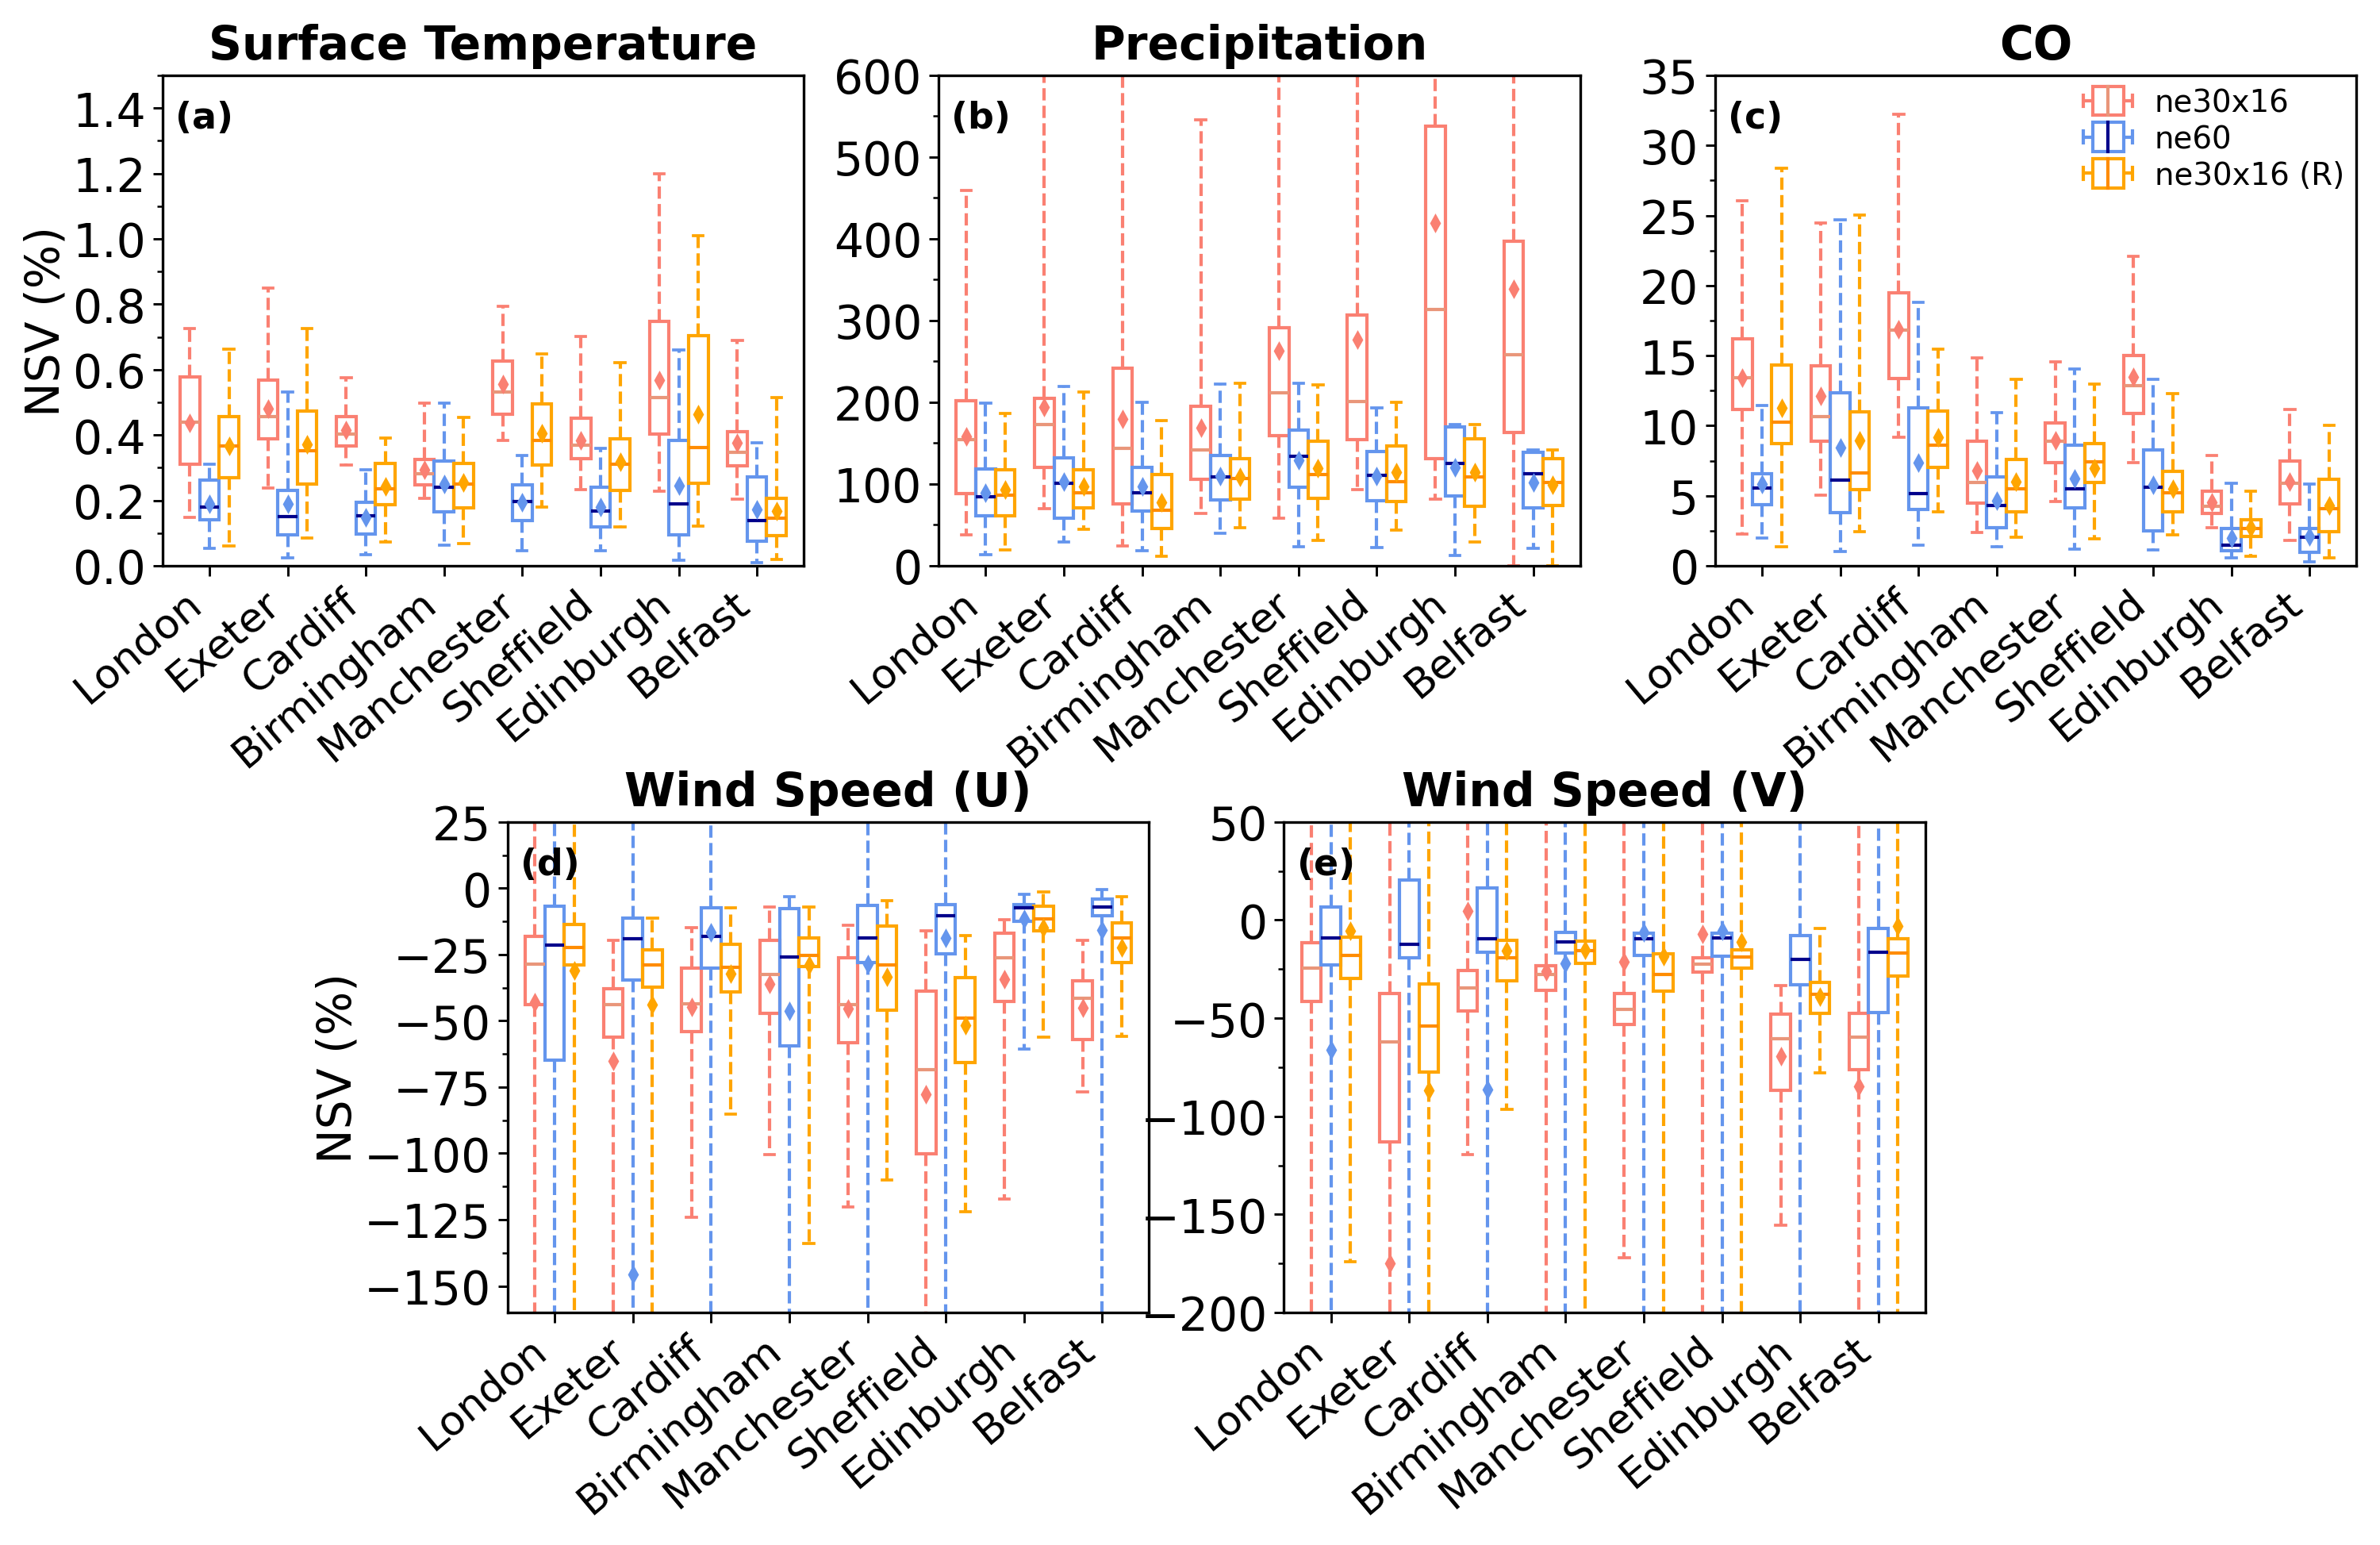

In [5]:
all_stats = {}
for cfg in configs:
    all_stats[cfg['name']] = load_and_compute_stats(
        cfg,
        cities,
        vars_model,
        box_deg=1.0,
        buffer_deg=0.2,
    )


def get_original_nsv_values(config_name, pollutant, city):
    values = np.asarray(all_stats[config_name][city][pollutant]['nsv'], dtype=np.float64)
    return values[np.isfinite(values)] * 100.0


fig_raw, axes_raw = draw_figure_s9(get_original_nsv_values)


In [6]:
os.makedirs(FIGURE_DATA_DIR, exist_ok=True)

nsv_lengths = []
for cfg in configs:
    for pollutant in pollutants:
        for city in cities:
            nsv_lengths.append(len(get_original_nsv_values(cfg['name'], pollutant, city)))

nsv_sample_count = max(nsv_lengths)
nsv_values = np.full(
    (len(configs), len(pollutants), len(cities), nsv_sample_count),
    np.nan,
    dtype=np.float64,
)

for icfg, cfg in enumerate(configs):
    cfg_name = cfg['name']
    for ipol, pollutant in enumerate(pollutants):
        for icity, city in enumerate(cities):
            values = get_original_nsv_values(cfg_name, pollutant, city)
            nsv_values[icfg, ipol, icity, :len(values)] = values

figure_s9_ds = xr.Dataset(
    data_vars={
        'nsv': (('nsv_config', 'pollutant', 'city', 'nsv_sample'), nsv_values),
    },
    coords={
        'nsv_config': [cfg['name'] for cfg in configs],
        'pollutant': pollutants,
        'city': cities,
        'nsv_sample': np.arange(nsv_sample_count, dtype=np.int32),
    },
)

for name in list(figure_s9_ds.data_vars) + list(figure_s9_ds.coords):
    figure_s9_ds[name].attrs = {}
figure_s9_ds.attrs = {}

figure_s9_ds.to_netcdf(FIGURE_S9_DATA_PATH)
figure_s9_ds.close()
print(FIGURE_S9_DATA_PATH)


/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS9.nc


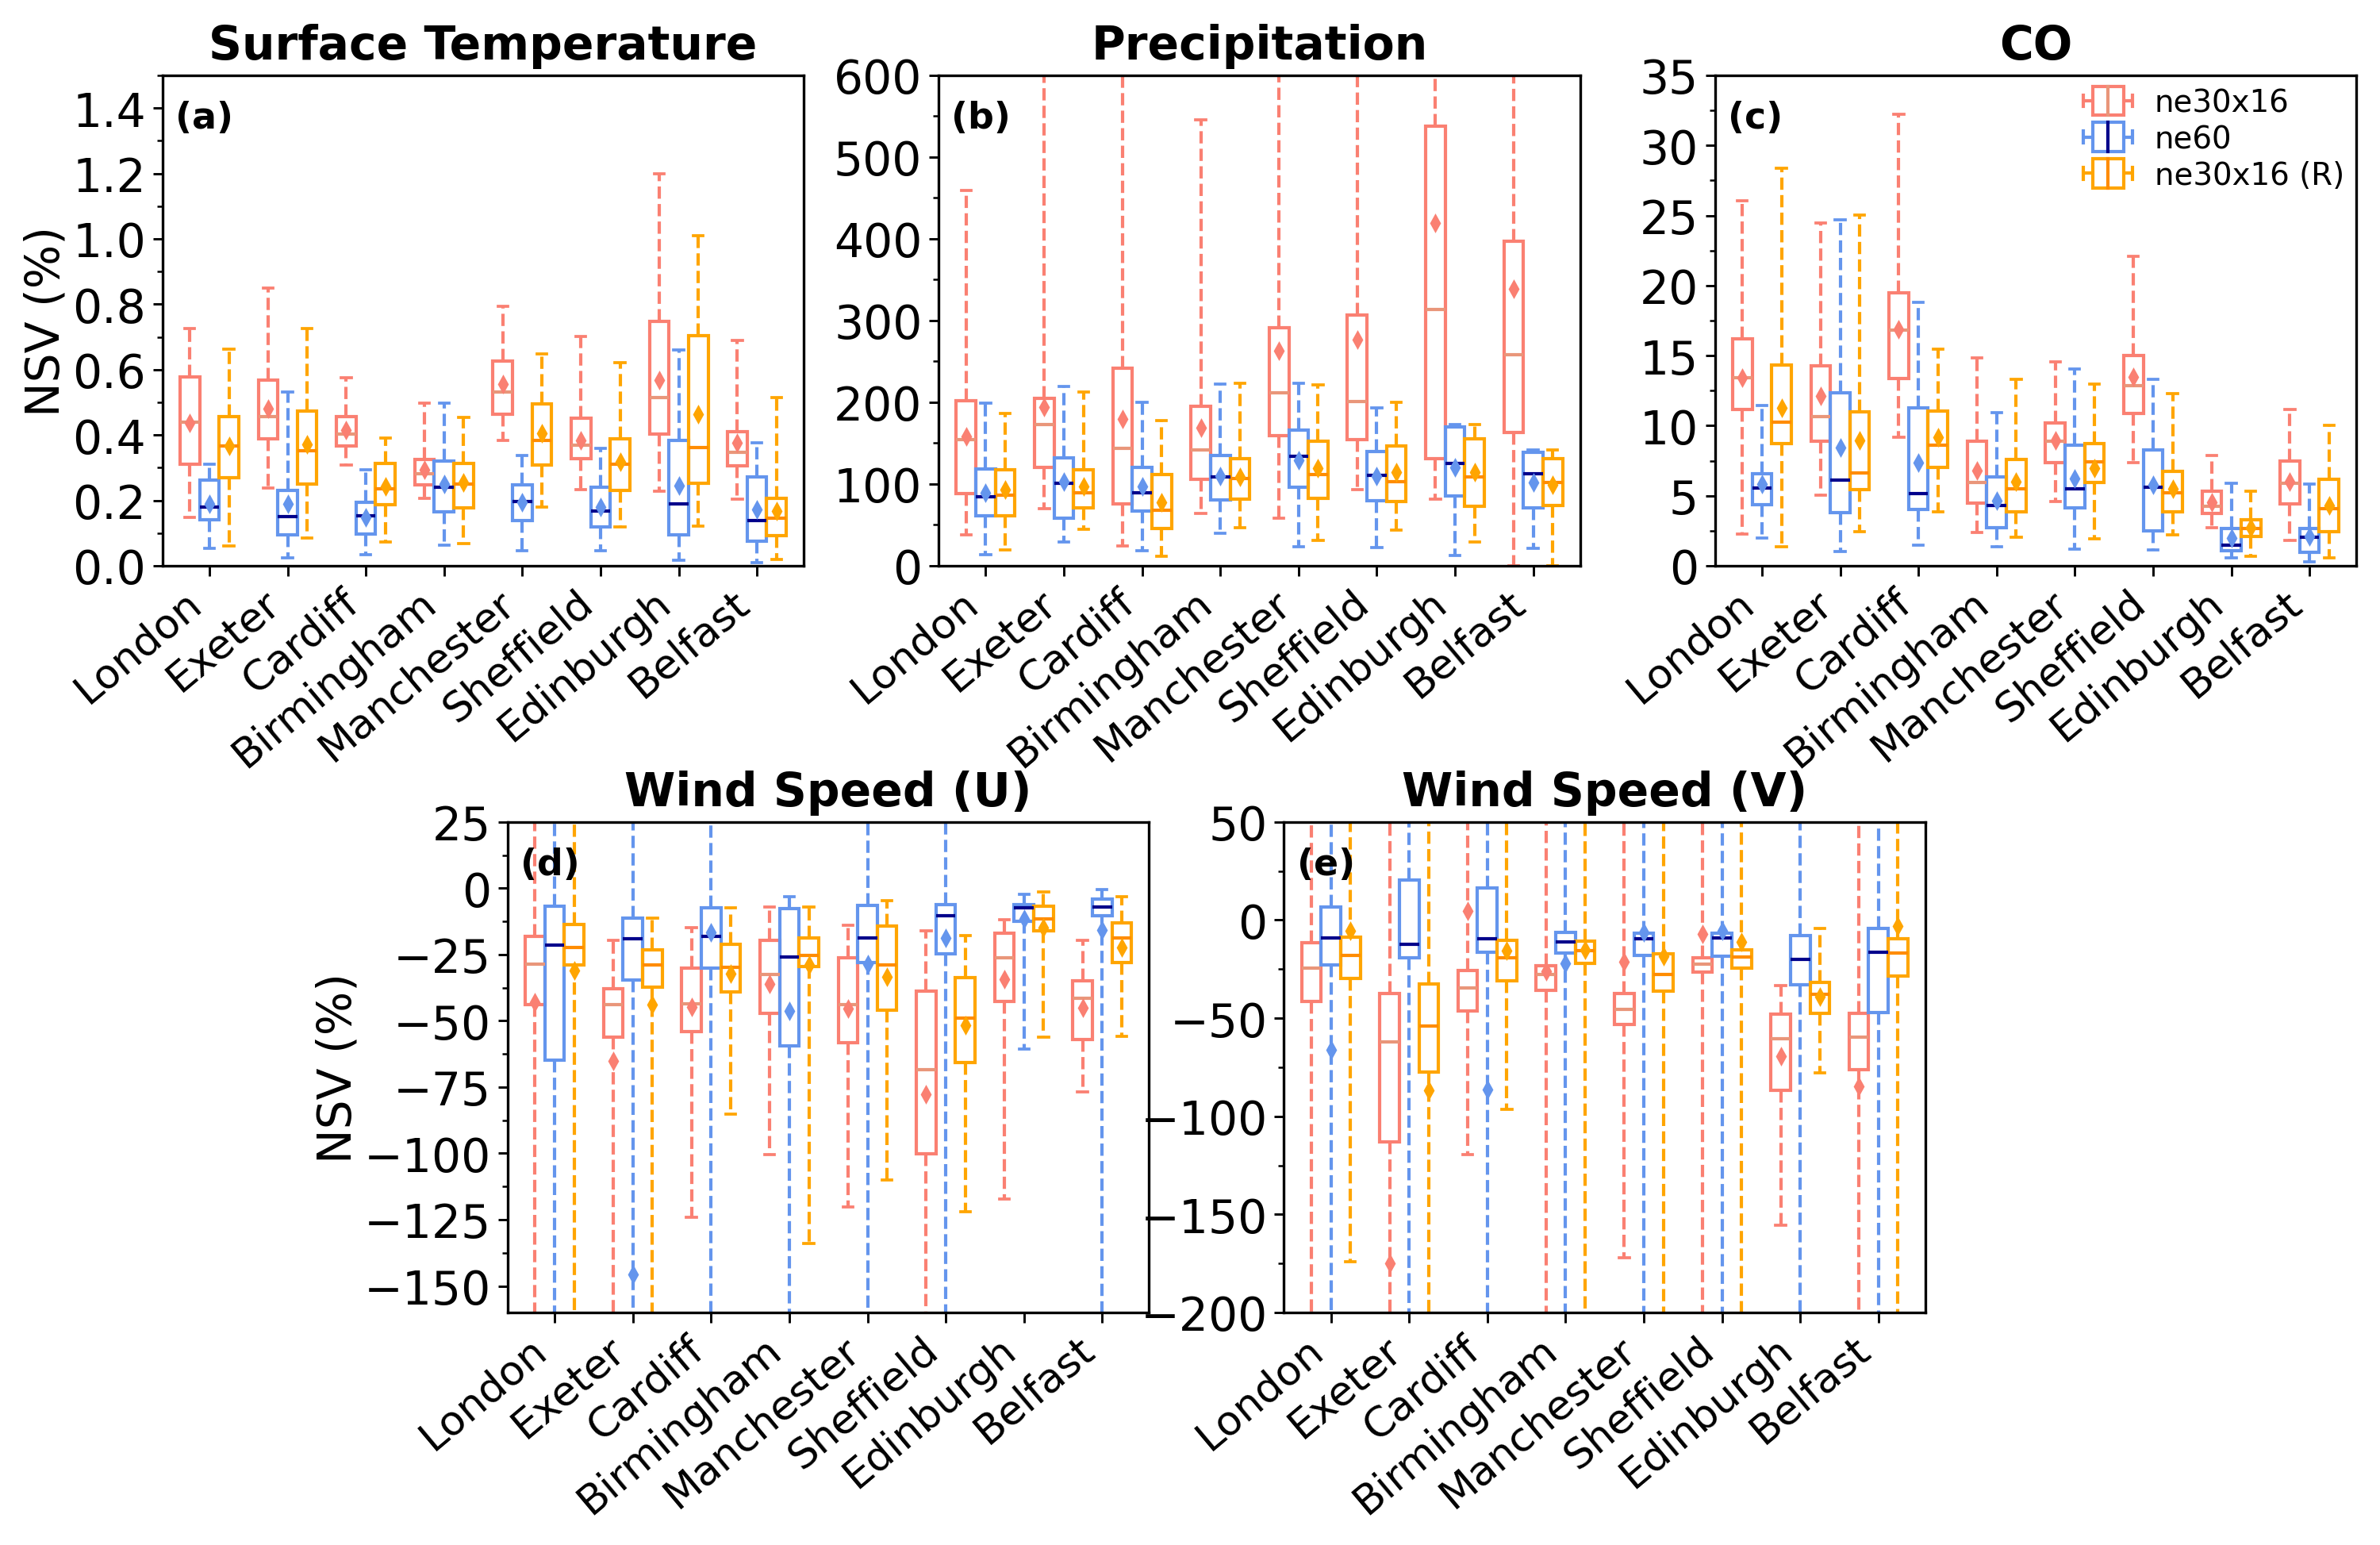

In [12]:
figure_s9_saved = xr.open_dataset(FIGURE_S9_DATA_PATH)

fig_saved = plt.figure(figsize=(10.3, 6.15), dpi=300)

left = 0.070
right = 0.965
top_gap = 0.055
panel_w = (right - left - 2 * top_gap) / 3
panel_h = 0.335
top_y = 0.595
bottom_y = 0.085

top_x = [left + i * (panel_w + top_gap) for i in range(3)]
bottom_gap = 0.055
bottom_left = (1 - (2 * panel_w + bottom_gap)) / 2
bottom_x = [bottom_left, bottom_left + panel_w + bottom_gap]

panel_specs = [
    ('Surface Temperature', [top_x[0], top_y, panel_w, panel_h], '(a)', True, False),
    ('Precipitation', [top_x[1], top_y, panel_w, panel_h], '(b)', False, False),
    ('CO', [top_x[2], top_y, panel_w, panel_h], '(c)', False, True),
    ('Wind Speed (U)', [bottom_x[0], bottom_y, panel_w, panel_h], '(d)', True, False),
    ('Wind Speed (V)', [bottom_x[1], bottom_y, panel_w, panel_h], '(e)', False, False),
]

axes_saved = {}
for pollutant, rect, panel_letter, show_ylabel, show_legend in panel_specs:
    ax = fig_saved.add_axes(rect)
    yset = nsv_yaxis_settings[pollutant]
    x = np.arange(len(cities))

    for j, cfg in enumerate(configs):
        cfg_name = cfg['name']
        sty = style_dicts[cfg_name]
        w = sty['box_width']
        positions = x + (j - (len(configs) - 1) / 2) * w
        data = []
        for city in cities:
            values = figure_s9_saved['nsv'].sel(
                nsv_config=cfg_name,
                pollutant=pollutant,
                city=city,
            ).values
            data.append(values[np.isfinite(values)])

        ax.boxplot(
            data,
            positions=positions,
            widths=w,
            whis=[0, 100],
            patch_artist=True,
            boxprops=dict(facecolor=sty['facecolor'],
                          edgecolor=sty['edgecolor'],
                          linewidth=sty['box_linewidth']),
            medianprops=dict(color=sty['median_color'],
                             linewidth=sty['median_linewidth']),
            whiskerprops=dict(color=sty['whisker_color'],
                              linewidth=sty['whisker_linewidth'],
                              linestyle='--'),
            capprops=dict(color=sty['cap_color'],
                          linewidth=sty['cap_linewidth']),
            showmeans=True,
            meanprops={
                'marker': 'd',
                'markerfacecolor': sty['mean_markeredgecolor'],
                'markeredgecolor': sty['mean_markeredgecolor'],
                'markeredgewidth': sty['mean_markeredgewidth'],
                'markersize': 3.0,
            },
        )

    ax.set_title(pollutant, fontsize=14, pad=5, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=40, ha='right', fontsize=12.5)
    ax.set_xlim(-0.6, len(cities) - 0.4)
    ax.set_ylim(*yset['ylim'])
    ax.yaxis.set_major_locator(MultipleLocator(yset['interval']))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(axis='y', which='major', labelsize=14, pad=2, length=3, width=0.7)
    ax.tick_params(axis='y', which='minor', length=1.8, width=0.6)
    ax.tick_params(axis='x', which='major', pad=2, length=3, width=0.7)
    ax.yaxis.set_tick_params(labelleft=True, labelright=False, left=True, right=False)

    if show_ylabel:
        ax.set_ylabel("NSV (%)", fontsize=14, labelpad=1)
    else:
        ax.set_ylabel("")

    ax.text(0.02, 0.95, panel_letter,
            transform=ax.transAxes, fontsize=11,
            fontweight='bold', va='top', ha='left')

    if show_legend:
        add_boxplot_legend(ax)
    axes_saved[pollutant] = ax

from pathlib import Path

FIGURES_DIR = Path("/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures/SI")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RASTER_DPI = 300
png_path = FIGURES_DIR / "FigureS9.png"
pdf_path = FIGURES_DIR / "FigureS9.pdf"

fig_saved.savefig(png_path, dpi=RASTER_DPI, bbox_inches="tight", facecolor="white")

img = plt.imread(png_path)
height_px, width_px = img.shape[:2]
pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
pdf_ax.imshow(img)
pdf_ax.axis("off")
pdf_fig.savefig(pdf_path, format="pdf", dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor="white")
plt.close(pdf_fig)
